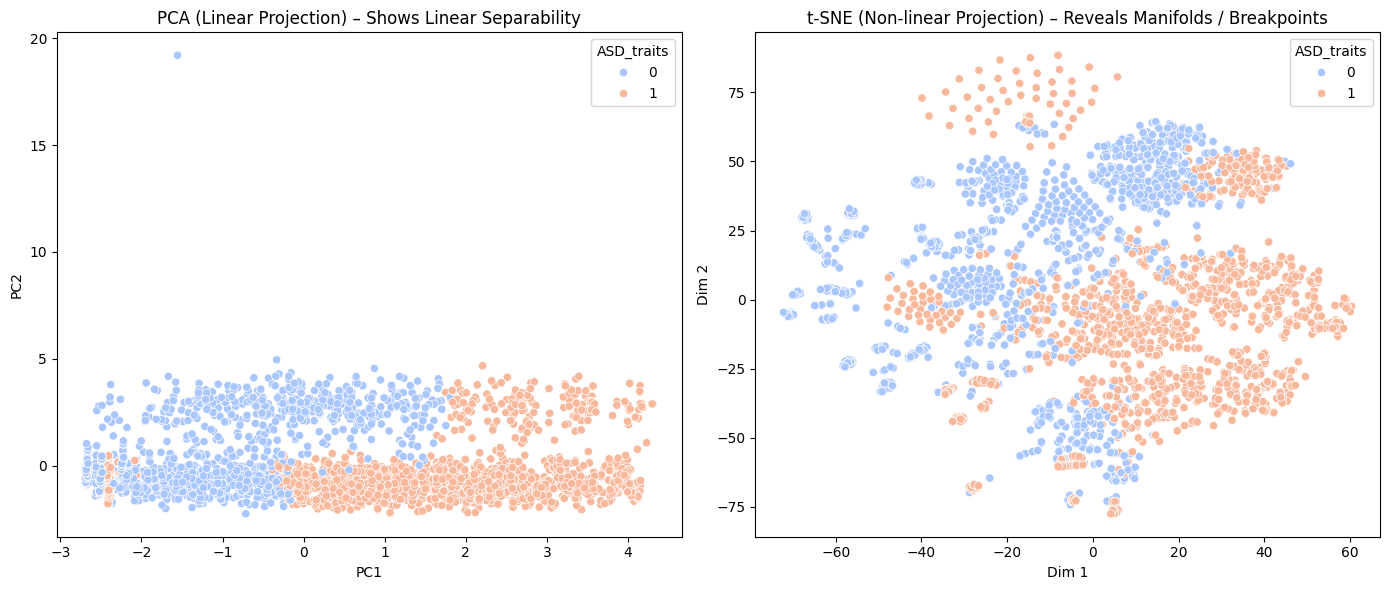

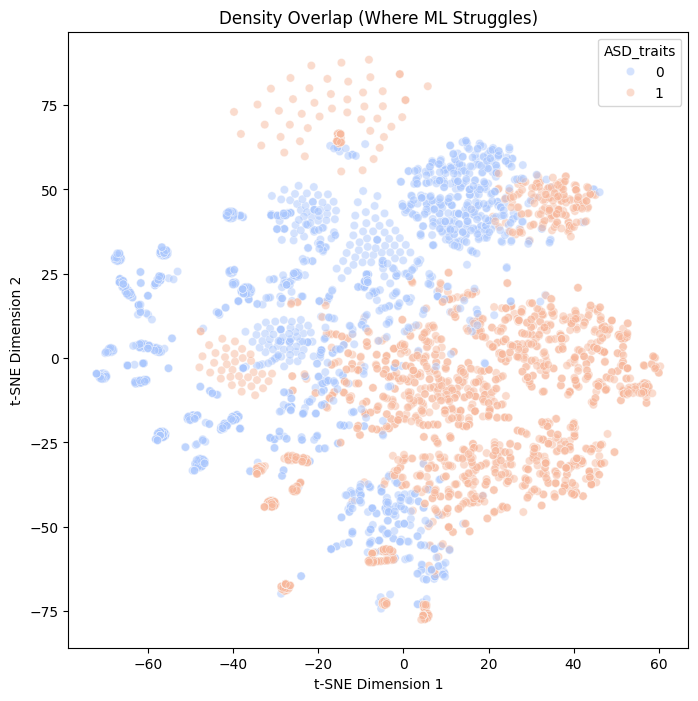

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Load dataset
# ------------------------------
df = pd.read_csv("data/data.csv")

# ------------------------------
# 2. Encode categorical columns
# ------------------------------
categorical_cols = ["Sex", "Ethnicity", "Jaundice", "Family_mem_with_ASD", 
                    "Who_completed_the_test", "ASD_traits"]

encoders = {}
for col in categorical_cols:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc

# ------------------------------
# 3. Separate features & label
# ------------------------------
X = df.drop(columns=["ASD_traits"])
y = df["ASD_traits"]

# ------------------------------
# 4. Standardize features
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------
# 5. Dimensionality Reduction
#   PCA (Linear) → Finds linear patterns
#   t-SNE (Non-linear) → Shows curved manifolds
# ------------------------------

# PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE (2D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# ------------------------------
# 6. PLOTS
# ------------------------------

plt.figure(figsize=(14,6))

# ----- PCA -----
plt.subplot(1, 2, 1)
plt.title("PCA (Linear Projection) – Shows Linear Separability")
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="coolwarm")
plt.xlabel("PC1")
plt.ylabel("PC2")

# ----- t-SNE -----
plt.subplot(1, 2, 2)
plt.title("t-SNE (Non-linear Projection) – Reveals Manifolds / Breakpoints")
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette="coolwarm")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Highlight Overlap Regions
#    These regions indicate where classical ML fails 
#    and QML might help due to complex manifolds.
# ------------------------------

from sklearn.neighbors import KernelDensity

plt.figure(figsize=(8,8))
plt.title("Density Overlap (Where ML Struggles)")

# KDE for class 0
kde0 = KernelDensity(bandwidth=0.6).fit(X_tsne[y==0])
kde1 = KernelDensity(bandwidth=0.6).fit(X_tsne[y==1])

# Draw scatter
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette="coolwarm", alpha=0.5)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()
